<h1 id="Lecture-4:-Roles-and-hand-offs">Lecture 4: Roles and hand-offs</h1><p>Data science creates value through connected responsibilities.  This demonstration treats a hand-off as a measurable risk point rather than an administrative detail.</p>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ds301.paths import project_root
COURSE_ROOT = project_root()
TEAL, MINT, GOLD, CORAL, INK = "#005F73", "#0A9396", "#E9C46A", "#E76F51", "#1F2933"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
handoffs = pd.read_csv(COURSE_ROOT / "data/project_handoffs.csv")
handoffs.head()

,handoff_id,from_role,to_role,artefact,days_waiting,accepted
0,1,analyst,operations,data dictionary,4,1
1,2,operations,analyst,pilot rule,8,0
2,3,operations,operations,data dictionary,2,1
3,4,analyst,operations,data dictionary,0,1
4,5,governance,analyst,pilot rule,0,1


<h2 id="Begin-with-the-records">Begin with the records</h2><p>Each row represents one hand-off of an artefact between roles. Inspect the sender, receiver, artefact, waiting time, and acceptance decision before colouring a heatmap. The heatmap should compress a pattern that students have already seen in the records.</p>

In [2]:
handoffs[["from_role", "to_role", "artefact", "days_waiting", "accepted"]].sample(12, random_state=301).sort_values("days_waiting", ascending=False)

,from_role,to_role,artefact,days_waiting,accepted
1,operations,analyst,pilot rule,8,0
74,engineer,operations,monitoring log,7,0
17,engineer,operations,validation report,7,0
75,operations,analyst,validation report,5,0
45,analyst,sponsor,pilot rule,3,1
81,operations,engineer,validation report,3,1
22,engineer,governance,monitoring log,3,0
11,analyst,sponsor,pilot rule,3,0
28,engineer,engineer,data dictionary,2,1
66,operations,sponsor,data dictionary,2,1


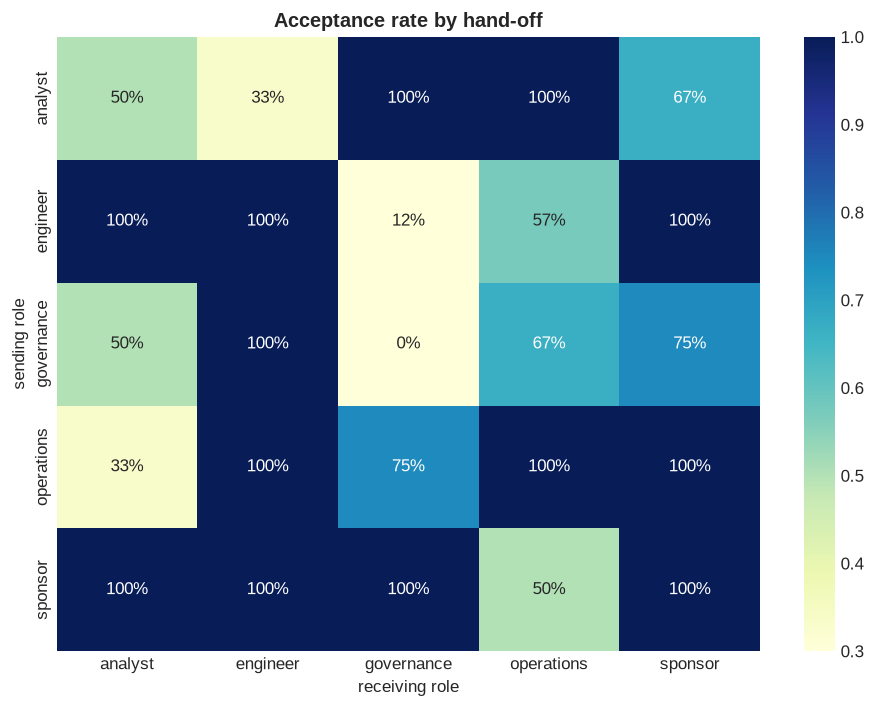

In [3]:
acceptance = handoffs.groupby(["from_role", "to_role"])["accepted"].agg(["mean", "size"]).reset_index()
pivot = acceptance.pivot(index="from_role", columns="to_role", values="mean")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="YlGnBu", vmin=.3, vmax=1, ax=ax)
ax.set(title="Acceptance rate by hand-off", xlabel="receiving role", ylabel="sending role")
plt.tight_layout()

In [4]:
handoffs.groupby("accepted")["days_waiting"].agg(["mean", "median", "size"]).round(2)

,mean,median,size
accepted,,,
0,4.74,5.0,23
1,1.82,1.5,62


<h2 id="The-ecosystem-around-a-decision">The ecosystem around a decision</h2><p>A data product requires more than one job title. The business sponsor owns the decision authority. Analysts frame and examine evidence. Engineers make data reliable. Governance functions set lawful and responsible boundaries. Operations own adoption and monitoring.</p>

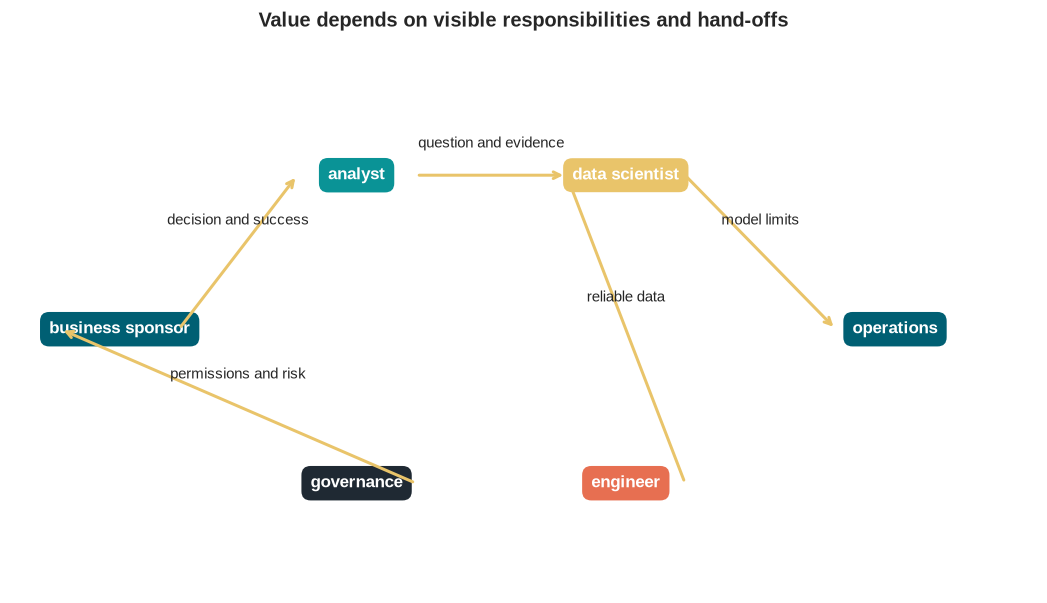

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
roles = {
    "business sponsor": (0, 1.6, TEAL), "analyst": (2.2, 2.6, MINT),
    "data scientist": (4.7, 2.6, GOLD), "engineer": (4.7, .6, CORAL),
    "operations": (7.2, 1.6, TEAL), "governance": (2.2, .6, INK),
}
for role, (x, y, colour) in roles.items():
    ax.text(x, y, role, ha="center", va="center", color="white", weight="bold", bbox=dict(boxstyle="round,pad=.55", fc=colour, ec="none"))
for start, end, label in [("business sponsor","analyst","decision and success"),("analyst","data scientist","question and evidence"),("engineer","data scientist","reliable data"),("data scientist","operations","model limits"),("governance","business sponsor","permissions and risk")]:
    x1,y1,_=roles[start]; x2,y2,_=roles[end]
    ax.annotate("",(x2-.55,y2),(x1+.55,y1),arrowprops=dict(arrowstyle="->",lw=1.8,color=GOLD))
    ax.text((x1+x2)/2,(y1+y2)/2+.18,label,ha="center",fontsize=9)
ax.set(xlim=(-1,8.5),ylim=(-.1,3.5),title="Value depends on visible responsibilities and hand-offs"); ax.axis("off")
plt.show()

<h2 id="Tools-support-capabilities">Tools support capabilities</h2><p>Choose a tool after naming the work it must support. A notebook, database, dashboard, model service, and audit log serve different capabilities.</p>

In [6]:
capability = pd.DataFrame({
    "capability": ["frame decision", "inspect evidence", "prepare and integrate", "model", "communicate", "monitor and govern"],
    "example tool family": ["decision canvas", "SQL, spreadsheet, notebook", "pipeline, database", "Python/R model", "dashboard, brief", "catalogue, alert, audit log"],
    "risk if missing": ["irrelevant output", "misread data", "inconsistent records", "unreliable prediction", "unused evidence", "unaccountable action"],
})
capability

,capability,example tool family,risk if missing
0,frame decision,decision canvas,irrelevant output
1,inspect evidence,"SQL, spreadsheet, notebook",misread data
2,prepare and integrate,"pipeline, database",inconsistent records
3,model,Python/R model,unreliable prediction
4,communicate,"dashboard, brief",unused evidence
5,monitor and govern,"catalogue, alert, audit log",unaccountable action


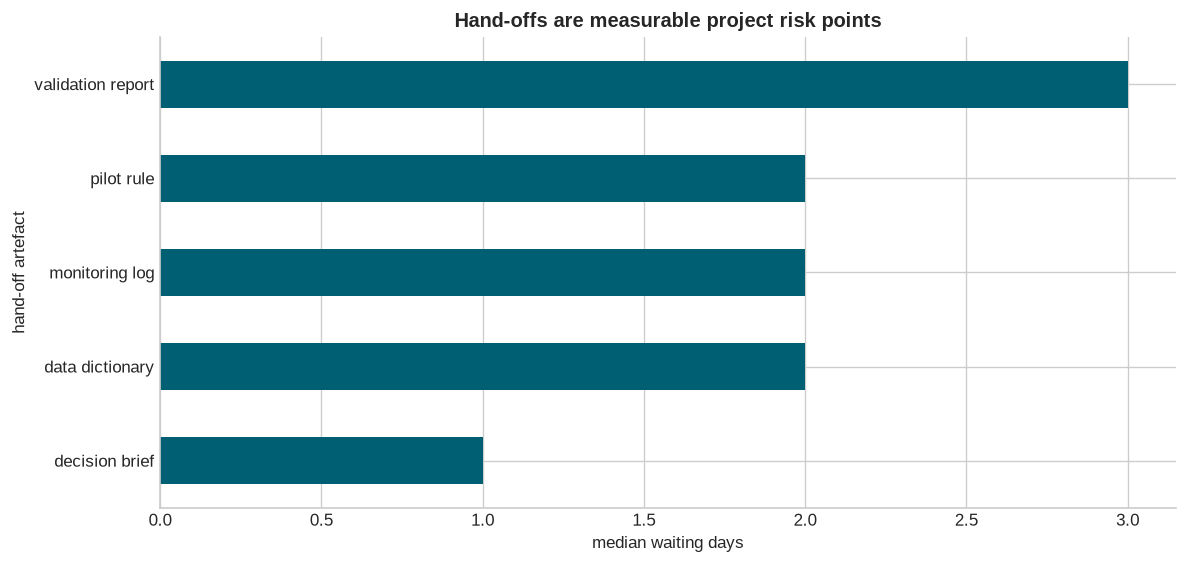

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.8))
waiting = handoffs.groupby("artefact").days_waiting.median().sort_values()
waiting.plot(kind="barh", color=TEAL, ax=ax)
ax.set(xlabel="median waiting days", ylabel="hand-off artefact", title="Hand-offs are measurable project risk points")
plt.tight_layout()

<h2 id="Responsible-hand-offs">Responsible hand-offs</h2><p>A team should specify an owner, an artefact, an acceptance rule, and an escalation route. A technically good model is unusable when no one can authorize, understand, or monitor its use.</p>

In [8]:
raci = pd.DataFrame({
    "deliverable": ["success metric", "trusted delivery data", "risk model", "pilot decision", "privacy review", "outcome monitoring"],
    "responsible": ["analyst", "data engineer", "data scientist", "operations", "governance", "operations"],
    "accountable": ["business sponsor", "engineering lead", "business sponsor", "business sponsor", "risk lead", "business sponsor"],
    "consulted": ["operations", "analyst", "operations", "data scientist", "legal", "analyst"],
    "informed": ["governance", "operations", "governance", "frontline team", "sponsor", "governance"],
})
raci

,deliverable,responsible,accountable,consulted,informed
0,success metric,analyst,business sponsor,operations,governance
1,trusted delivery data,data engineer,engineering lead,analyst,operations
2,risk model,data scientist,business sponsor,operations,governance
3,pilot decision,operations,business sponsor,data scientist,frontline team
4,privacy review,governance,risk lead,legal,sponsor
5,outcome monitoring,operations,business sponsor,analyst,governance


<h2 id="Follow-the-data-journey,-not-just-the-data-product">Follow the data journey, not just the data product</h2><p>Records are first created for an operational purpose. They are then transferred and transformed for analysis, used in a decision, and followed by outcome data for learning. Every transition can change meaning, access, or reliability.</p>

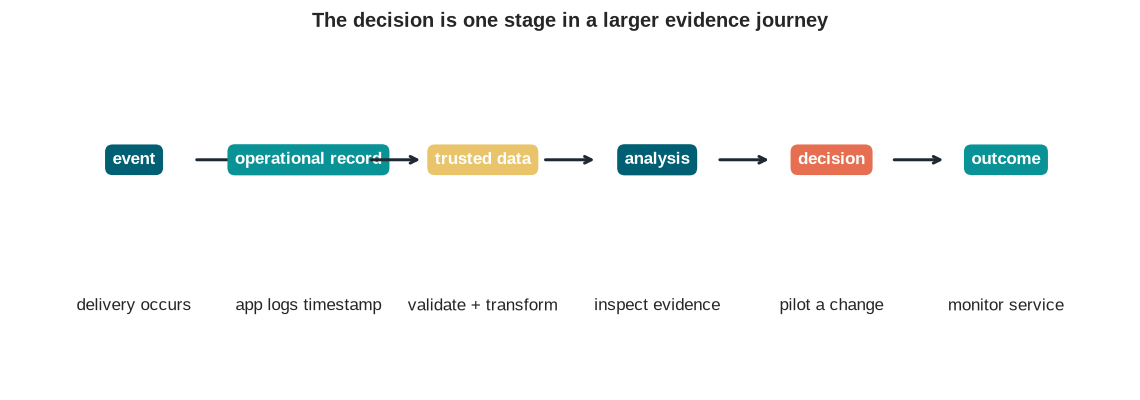

In [9]:
fig, ax = plt.subplots(figsize=(12, 3.8))
journey = [
    ("event", "delivery occurs"), ("operational record", "app logs timestamp"),
    ("trusted data", "validate + transform"), ("analysis", "inspect evidence"),
    ("decision", "pilot a change"), ("outcome", "monitor service"),
]
for i, (stage, detail) in enumerate(journey):
    colour = [TEAL, MINT, GOLD, TEAL, CORAL, MINT][i]
    ax.text(i, .78, stage, ha="center", va="center", color="white", weight="bold",
            bbox=dict(boxstyle="round,pad=.45", fc=colour, ec="none"))
    ax.text(i, .28, detail, ha="center", va="center")
    if i < len(journey) - 1:
        ax.annotate("", (i + .66, .78), (i + .34, .78), arrowprops=dict(arrowstyle="->", color=INK, lw=1.8))
ax.set(xlim=(-.7, 5.7), ylim=(0, 1.2), title="The decision is one stage in a larger evidence journey")
ax.axis("off")
plt.show()

<h2 id="Select-tools-after-naming-the-capability">Select tools after naming the capability</h2><p>A spreadsheet can be the right tool for a small, one-off decision. A pipeline, model service, or catalogue becomes useful only when scale, repetition, integration, or risk demands it.</p>

In [10]:
tool_choice = pd.DataFrame({
    "need": ["small one-off comparison", "repeatable reporting", "large reliable data", "live model use", "sensitive/high-impact use"],
    "proportionate support": ["spreadsheet or notebook", "versioned query + dashboard", "documented pipeline + database", "service + monitoring", "access controls + audit + review"],
    "selection question": ["Can a simple check answer it?", "Who needs a refreshed view?", "How is lineage maintained?", "Can the user override safely?", "Can purpose and access be justified?"],
})
tool_choice

,need,proportionate support,selection question
0,small one-off comparison,spreadsheet or notebook,Can a simple check answer it?
1,repeatable reporting,versioned query + dashboard,Who needs a refreshed view?
2,large reliable data,documented pipeline + database,How is lineage maintained?
3,live model use,service + monitoring,Can the user override safely?
4,sensitive/high-impact use,access controls + audit + review,Can purpose and access be justified?


<h3 id="Student-activity">Student activity</h3><p>Select the hand-off you would repair first.  Name the artefact, its owner, the acceptance rule, and the consequence of an ambiguous hand-off.</p>

<h2 id="Applied-hand-off-lab:-the-analytics-ready-dataset">Applied hand-off lab: the analytics-ready dataset</h2><p>A good hand-off includes more than a file. The real Wine Recognition dataset illustrates a practical contract: the source owner supplies the observations and definitions, the analyst inspects ranges and coverage, and the modeller receives a reproducible feature matrix.</p>

In [11]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine_case = load_wine(as_frame=True)
wine_raw = wine_case.frame
wine_raw[["alcohol", "malic_acid", "color_intensity", "target"]].head(8)

,alcohol,malic_acid,color_intensity,target
0,14.23,1.71,5.64,0
1,13.20,1.78,4.38,0
2,13.16,2.36,5.68,0
3,14.37,1.95,7.80,0
4,13.24,2.59,4.32,0
5,14.20,1.76,6.75,0
6,14.39,1.87,5.25,0
7,14.06,2.15,5.05,0


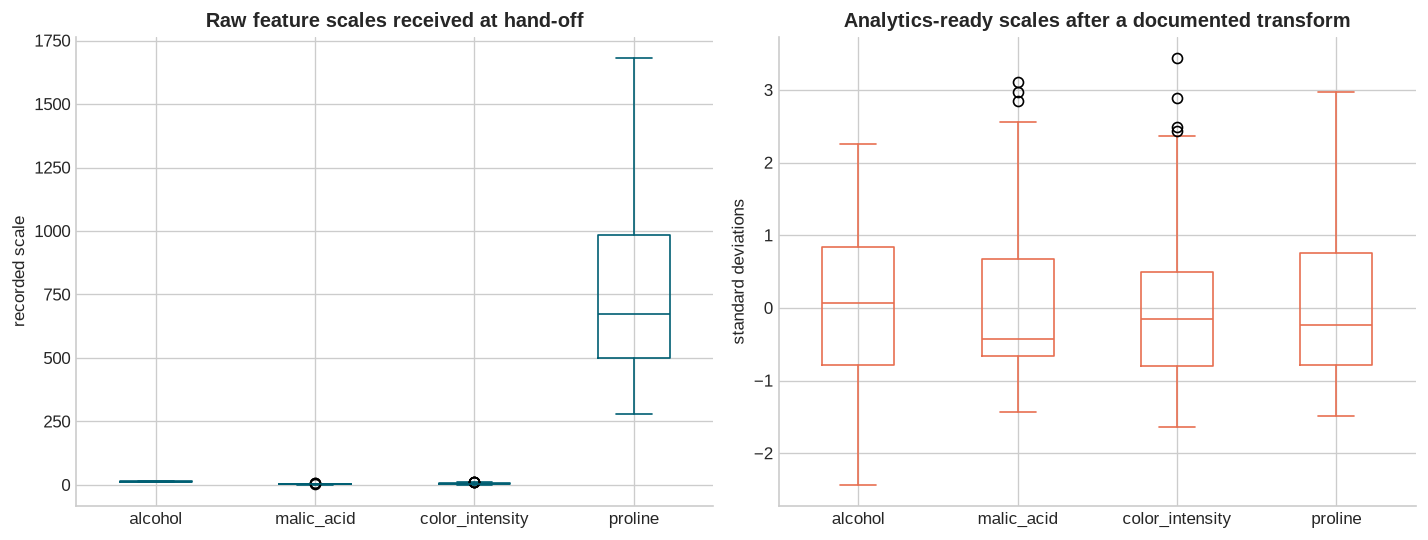

In [12]:
selected = ["alcohol", "malic_acid", "color_intensity", "proline"]
scaled = pd.DataFrame(StandardScaler().fit_transform(wine_raw[selected]), columns=selected)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
wine_raw[selected].plot(kind="box", ax=axes[0], color=TEAL)
axes[0].set(title="Raw feature scales received at hand-off", ylabel="recorded scale")
scaled.plot(kind="box", ax=axes[1], color=CORAL)
axes[1].set(title="Analytics-ready scales after a documented transform", ylabel="standard deviations")
plt.tight_layout()

<p>Scaling is a modeller's transformation, not a replacement for the source data. The hand-off should preserve the source, the transformation code, and the intended use of every column.</p>

### Lecture application

Assign a source owner to the measurement definitions, an analyst to the audit, a modeller to the pipeline, and a decision owner to acceptance. Define what each receiver checks before accepting the hand-off.

## Worked project: identifying wine cultivars from measured chemistry

**Question:** can chemical measurements identify the recorded cultivar of an unseen wine sample? The UCI Wine Recognition dataset has 178 measured samples, 13 input features and three cultivar labels. A laboratory could use such a model as a screening aid. This small historical sample cannot establish performance on every producer or future vintage.

We will inspect rows and units, reserve test records, establish a majority-class baseline, select a model using training folds, inspect errors, and write a decision statement. The class label is the outcome, so it never enters the feature matrix. No download is required because scikit-learn bundles these observations.

In [13]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay
project_data = load_wine(as_frame=True)
project_X, project_y = project_data.data, project_data.target
display(project_data.frame.head(8))
display(pd.DataFrame({'dtype':project_X.dtypes.astype(str), 'missing':project_X.isna().sum(),
                      'minimum':project_X.min(), 'maximum':project_X.max()}).round(3))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0


,dtype,missing,minimum,maximum
alcohol,float64,0,11.03,14.83
malic_acid,float64,0,0.74,5.80
ash,float64,0,1.36,3.23
alcalinity_of_ash,float64,0,10.60,30.00
magnesium,float64,0,70.00,162.00
total_phenols,float64,0,0.98,3.88
flavanoids,float64,0,0.34,5.08
nonflavanoid_phenols,float64,0,0.13,0.66
proanthocyanins,float64,0,0.41,3.58
color_intensity,float64,0,1.28,13.00


### Inspect the observations before choosing a model

The scatter compares two recorded features. The counts show how many examples represent each class. A two-feature view may hide separation present in the other measurements. A random stratified split assumes that these records represent the unseen samples of interest; new producers or later vintages would need a different evaluation design.

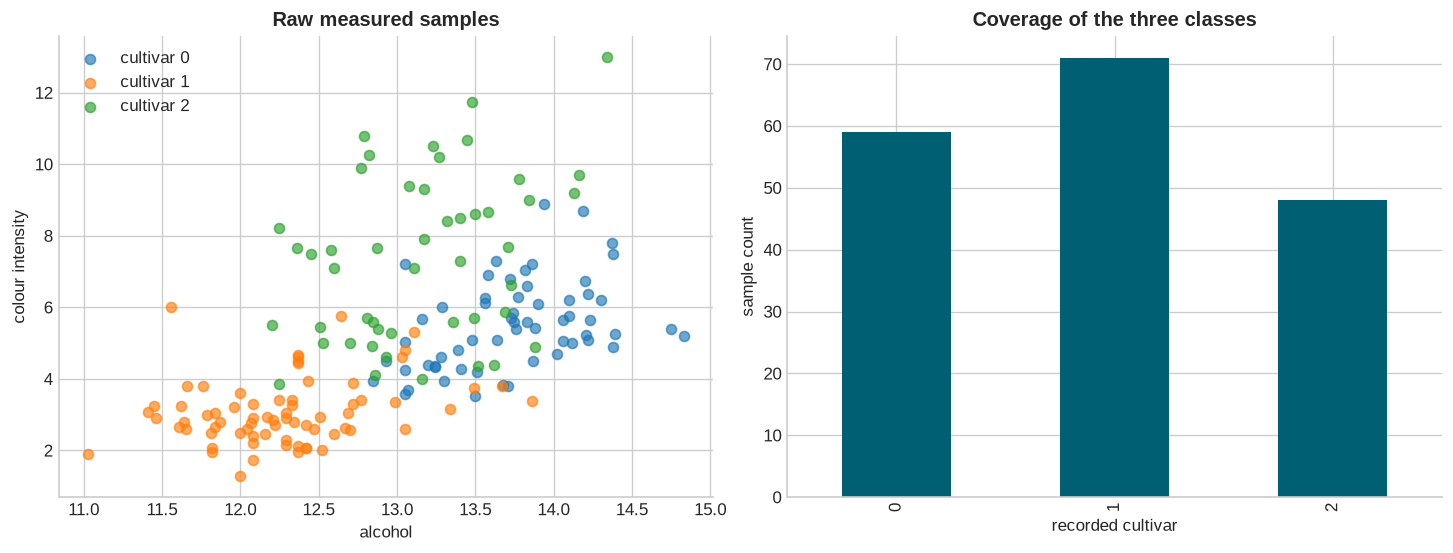

In [14]:
fig, axes = plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
for label in np.unique(project_y):
    selected = project_y==label
    axes[0].scatter(project_X.loc[selected,'alcohol'],project_X.loc[selected,'color_intensity'],label=f'cultivar {label}',alpha=.65)
axes[0].set(xlabel='alcohol',ylabel='colour intensity',title='Raw measured samples'); axes[0].legend()
project_y.value_counts().sort_index().plot.bar(ax=axes[1],color='#005F73')
axes[1].set(xlabel='recorded cultivar',ylabel='sample count',title='Coverage of the three classes'); plt.show()
project_train, project_test, target_train, target_test = train_test_split(project_X,project_y,test_size=.25,stratify=project_y,random_state=301)

### Fit a baseline, then select a model using training folds

The baseline always predicts the most common training class. The learned model scales features inside each training fold and estimates logistic probabilities. The validation table selects the regularisation setting using only training data. `C` is inverse regularisation strength: a smaller value applies stronger shrinkage.

,C,validation balanced accuracy,fold SD
0,0.01,0.981,0.026
1,0.10,0.981,0.026
2,1.00,0.972,0.026
3,10.00,0.964,0.022


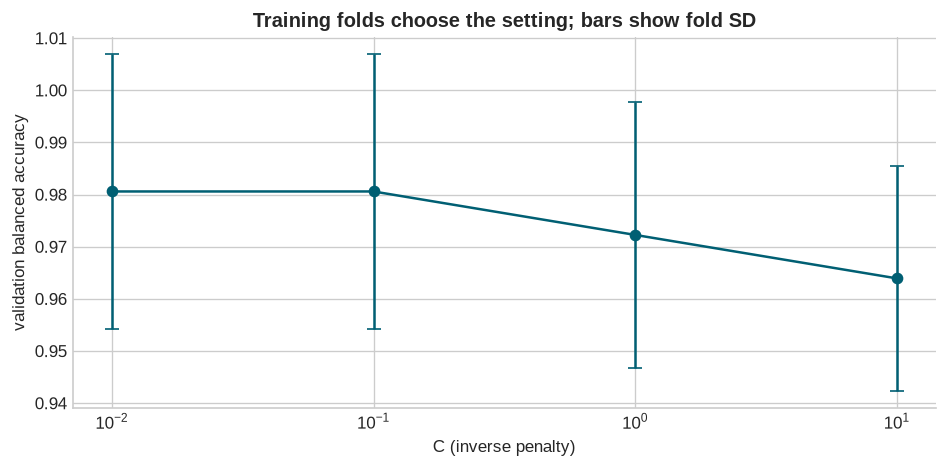

In [15]:
project_baseline = DummyClassifier(strategy='most_frequent').fit(project_train,target_train)
project_cv = StratifiedKFold(5,shuffle=True,random_state=301)
project_search = GridSearchCV(make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000)),
                             {'logisticregression__C':[.01,.1,1,10]},cv=project_cv,scoring='balanced_accuracy')
project_search.fit(project_train,target_train)
cv_table = pd.DataFrame(project_search.cv_results_)[['param_logisticregression__C','mean_test_score','std_test_score']]
display(cv_table.rename(columns={'param_logisticregression__C':'C','mean_test_score':'validation balanced accuracy','std_test_score':'fold SD'}).round(3))
fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(cv_table.iloc[:,0].astype(float),cv_table.iloc[:,1],yerr=cv_table.iloc[:,2],fmt='o-',capsize=4,color='#005F73')
ax.set(xscale='log',xlabel='C (inverse penalty)',ylabel='validation balanced accuracy',title='Training folds choose the setting; bars show fold SD')
plt.tight_layout(); plt.show()

### Open the held-out set once and inspect the errors

The confusion matrix counts actual outcomes, rather than compressing every error into one score. Each row refers to the true cultivar. Off-diagonal cells show which classes the fitted model confuses. These counts are small, so a high score on this split has substantial sampling uncertainty.

,model,test accuracy,test balanced accuracy
0,majority baseline,0.4,0.333
1,selected logistic model,1.0,1.000


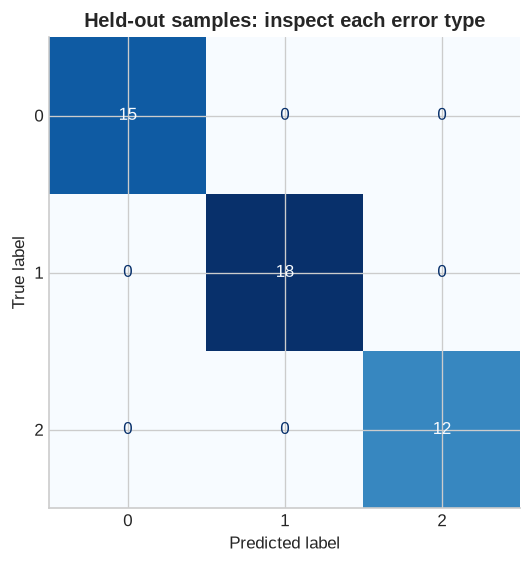

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,observed cultivar,predicted cultivar,highest probability
43,13.24,3.98,2.29,17.5,103.0,2.64,2.63,0.32,1.66,4.36,0.82,3.00,680.0,0,0,0.410
130,12.86,1.35,2.32,18.0,122.0,1.51,1.25,0.21,0.94,4.10,0.76,1.29,630.0,2,2,0.436
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,0,0.490
118,12.77,3.43,1.98,16.0,80.0,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372.0,1,1,0.509
96,11.81,2.12,2.74,21.5,134.0,1.60,0.99,0.14,1.56,2.50,0.95,2.26,625.0,1,1,0.537
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1,1,0.540
65,12.37,1.21,2.56,18.1,98.0,2.42,2.65,0.37,2.08,4.60,1.19,2.30,678.0,1,1,0.554
71,13.86,1.51,2.67,25.0,86.0,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410.0,1,1,0.555


In [16]:
project_pred = project_search.predict(project_test)
baseline_pred = project_baseline.predict(project_test)
display(pd.DataFrame({'model':['majority baseline','selected logistic model'],
                      'test accuracy':[accuracy_score(target_test,baseline_pred),accuracy_score(target_test,project_pred)],
                      'test balanced accuracy':[balanced_accuracy_score(target_test,baseline_pred),balanced_accuracy_score(target_test,project_pred)]}).round(3))
fig,ax=plt.subplots(figsize=(6,4.8))
ConfusionMatrixDisplay.from_predictions(target_test,project_pred,ax=ax,cmap='Blues',colorbar=False)
ax.set_title('Held-out samples: inspect each error type'); plt.tight_layout(); plt.show()
project_review=project_test.copy()
project_review['observed cultivar']=target_test
project_review['predicted cultivar']=project_pred
project_review['highest probability']=project_search.predict_proba(project_test).max(axis=1)
display(project_review.sort_values('highest probability').head(8).round(3))

### Decision statement and next evidence

Compare the selected model with the baseline using the table above. State the held-out sample size and the errors you see. A laboratory would next validate new samples from its own measurement process and agree when a prediction requires manual review. Monitoring would track missing measurements, feature ranges, class frequencies, and verified errors. Confidence scores need calibration evidence before they can justify an automatic acceptance threshold.